# **Importing Libraries**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# **Mounting the Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Checking Wheather the Dataset is Biased or Not**

## **Loading Dataset**

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/GENAI_PROJECT/EVChargingStationUsage.csv')

/tmp/ipykernel_6341/1150367506.py:1: DtypeWarning: Columns (29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/GENAI_PROJECT/EVChargingStationUsage.csv')


## **Checking**

In [5]:
df.columns

Index(['Station Name', 'MAC Address', 'Org Name', 'Start Date',
       'Start Time Zone', 'End Date', 'End Time Zone',
       'Transaction Date (Pacific Time)', 'Total Duration (hh:mm:ss)',
       'Charging Time (hh:mm:ss)', 'Energy (kWh)', 'GHG Savings (kg)',
       'Gasoline Savings (gallons)', 'Port Type', 'Port Number', 'Plug Type',
       'EVSE ID', 'Address 1', 'City', 'State/Province', 'Postal Code',
       'Country', 'Latitude', 'Longitude', 'Currency', 'Fee', 'Ended By',
       'Plug In Event Id', 'Driver Postal Code', 'User ID', 'County',
       'System S/N', 'Model Number'],
      dtype='object')

In [6]:
df['Station Name'].nunique()
df['Station Name'].value_counts(normalize=True).head()

,proportion
Station Name,
PALO ALTO CA / HAMILTON #2,0.091440
PALO ALTO CA / HAMILTON #1,0.057391
PALO ALTO CA / WEBSTER #1,0.055633
PALO ALTO CA / BRYANT #2,0.055467
PALO ALTO CA / HIGH #4,0.053574


In [7]:
print("Unique Stations:", df['Station Name'].nunique())
df['Station Name'].value_counts().head(10)

Unique Stations: 47


,count
Station Name,
PALO ALTO CA / HAMILTON #2,23721
PALO ALTO CA / HAMILTON #1,14888
PALO ALTO CA / WEBSTER #1,14432
PALO ALTO CA / BRYANT #2,14389
PALO ALTO CA / HIGH #4,13898
PALO ALTO CA / BRYANT #1,13436
PALO ALTO CA / WEBSTER #2,12669
PALO ALTO CA / CAMBRIDGE #1,11163
PALO ALTO CA / HIGH #1,10756


In [8]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['Hour'] = df['Start Date'].dt.hour
df['Weekday'] = df['Start Date'].dt.weekday


In [9]:
print("Unique Hours:", df['Hour'].nunique())
print("Unique Weekdays:", df['Weekday'].nunique())

Unique Hours: 24
Unique Weekdays: 7


In [10]:
df['Hour'].nunique()
df['Weekday'].nunique()

7

In [11]:
df['Energy (kWh)'].describe()

,Energy (kWh)
count,259415.000000
mean,8.544277
std,7.185462
min,0.010000
25%,3.784000
50%,6.868634
75%,11.458340
max,97.360000


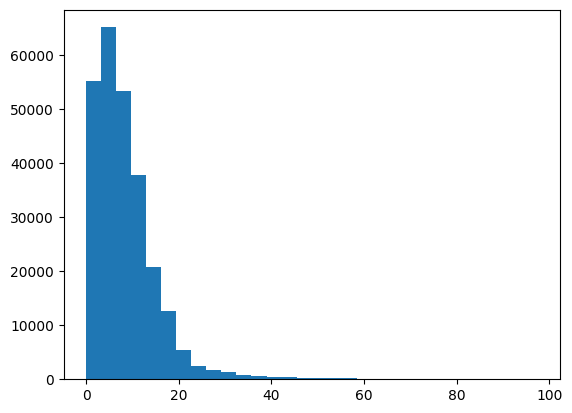

In [12]:
import matplotlib.pyplot as plt
plt.hist(df['Energy (kWh)'], bins=30)
plt.show()

In [13]:
df_grouped = df.groupby(['Station Name', 'Hour'])['Energy (kWh)'].sum().reset_index()

In [14]:
print("Stations:", df['Station Name'].nunique())
print("Hours:", df['Hour'].nunique())
print("Weekdays:", df['Weekday'].nunique())

Stations: 47
Hours: 24
Weekdays: 7


In [15]:
df['City'].value_counts(normalize=True)

,proportion
City,
Palo Alto,1.0


### The dataset shows good spatial and temporal diversity with 47 stations, full 24-hour coverage, and all weekdays represented. While the energy consumption distribution is right-skewed, this reflects natural EV charging behavior rather than structural bias.

# **Data Cleaning**


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 35 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Station Name                     259415 non-null  object        
 1   MAC Address                      259415 non-null  object        
 2   Org Name                         259415 non-null  object        
 3   Start Date                       259415 non-null  datetime64[ns]
 4   Start Time Zone                  259415 non-null  object        
 5   End Date                         259415 non-null  object        
 6   End Time Zone                    259415 non-null  object        
 7   Transaction Date (Pacific Time)  259206 non-null  object        
 8   Total Duration (hh:mm:ss)        259415 non-null  object        
 9   Charging Time (hh:mm:ss)         259415 non-null  object        
 10  Energy (kWh)                     259415 non-

In [17]:
df.shape

(259415, 35)

In [18]:
##these are unnecessary columns

df = df.drop(columns=[
    'MAC Address',
    'User ID',
    'Plug In Event Id',
    'Driver Postal Code',
    'System S/N',
    'Model Number',
    'Start Time Zone',
    'End Time Zone',
    'Transaction Date (Pacific Time)',
    'Address 1',
    'Postal Code',
    'Currency'
])

In [19]:
##these columns have the too many missing values

df = df.drop(columns=['EVSE ID', 'County'])

In [20]:
##removing non-zero energy sessions

df = df[df['Energy (kWh)'] > 0] #non-zero doesn't represent demand

In [21]:
df['Charging Time (hh:mm:ss)'] = pd.to_timedelta(df['Charging Time (hh:mm:ss)'])
df['Charging_Time_Minutes'] = df['Charging Time (hh:mm:ss)'].dt.total_seconds() / 60

df['Total Duration (hh:mm:ss)'] = pd.to_timedelta(df['Total Duration (hh:mm:ss)'])
df['Total_Duration_Minutes'] = df['Total Duration (hh:mm:ss)'].dt.total_seconds() / 60

In [22]:
df = df[[
    'Station Name',
    'City',
    'State/Province',
    'Country',
    'Latitude',
    'Longitude',
    'Port Type',
    'Plug Type',
    'Fee',
    'Energy (kWh)',
    'Charging_Time_Minutes',
    'Total_Duration_Minutes',
    'Hour',
    'Weekday'
]]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Station Name            259415 non-null  object 
 1   City                    259415 non-null  object 
 2   State/Province          259415 non-null  object 
 3   Country                 259415 non-null  object 
 4   Latitude                259415 non-null  float64
 5   Longitude               259415 non-null  float64
 6   Port Type               259406 non-null  object 
 7   Plug Type               259415 non-null  object 
 8   Fee                     259415 non-null  float64
 9   Energy (kWh)            259415 non-null  float64
 10  Charging_Time_Minutes   259415 non-null  float64
 11  Total_Duration_Minutes  259415 non-null  float64
 12  Hour                    259415 non-null  int32  
 13  Weekday                 259415 non-null  int32  
dtypes: float64(6), int32

In [24]:
df.shape

(259415, 14)

In [25]:
df_grouped = df.groupby(['Station Name', 'Hour', 'Weekday'])['Energy (kWh)'].sum().reset_index()

In [26]:
df.shape

(259415, 14)

In [27]:
df.isnull().sum().sum()

np.int64(9)

In [28]:
df.isnull().sum()

,0
Station Name,0
City,0
State/Province,0
Country,0
Latitude,0
Longitude,0
Port Type,9
Plug Type,0
Fee,0
Energy (kWh),0


In [29]:
df['Port Type'] = df['Port Type'].fillna(df['Port Type'].mode()[0])

In [30]:
df.isnull().sum()

,0
Station Name,0
City,0
State/Province,0
Country,0
Latitude,0
Longitude,0
Port Type,0
Plug Type,0
Fee,0
Energy (kWh),0


In [31]:
df['Port Type'].value_counts()

,count
Port Type,
Level 2,254736
Level 1,4679


In [32]:
## we drop this becuase of the imbalance

df = df.drop(columns=['Port Type'])

# **Data Featuring & Pre Processing**

In [33]:
df_grouped.head()

,Station Name,Hour,Weekday,Energy (kWh)
0,PALO ALTO CA / BRYANT # 1,0,2,1.480
1,PALO ALTO CA / BRYANT # 1,0,6,2.830
2,PALO ALTO CA / BRYANT # 1,9,2,42.064
3,PALO ALTO CA / BRYANT # 1,10,2,11.834
4,PALO ALTO CA / BRYANT # 1,11,6,5.355


In [34]:
df_grouped.shape

(4827, 4)

In [35]:
df_grouped['Peak_Hour'] = df_grouped['Hour'].apply(
    lambda x: 1 if (6 <= x <= 10) or (17 <= x <= 21) else 0
)

In [36]:
df_grouped['Is_Weekend'] = df_grouped['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

In [37]:
station_avg = df_grouped.groupby('Station Name')['Energy (kWh)'].mean()
df_grouped['Station_Avg_Load'] = df_grouped['Station Name'].map(station_avg)

In [38]:
df_grouped['Hour_Weekend_Interaction'] = df_grouped['Hour'] * df_grouped['Is_Weekend']

##**Using One-Hot Encoding to encode the Stations**

In [39]:
df_grouped.columns

Index(['Station Name', 'Hour', 'Weekday', 'Energy (kWh)', 'Peak_Hour',
       'Is_Weekend', 'Station_Avg_Load', 'Hour_Weekend_Interaction'],
      dtype='object')

In [40]:
df_grouped = pd.get_dummies(df_grouped, columns=['Station Name'], drop_first=True)

In [41]:
## Defined Feature and Target

X = df_grouped.drop(columns=['Energy (kWh)'])
y = df_grouped['Energy (kWh)']

In [42]:
##Train-Test Spit

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Peak hour indicator
df_grouped['Peak_Hour'] = df_grouped['Hour'].apply(
    lambda x: 1 if (6 <= x <= 10) or (17 <= x <= 21) else 0
)

In [44]:
# Weekend indicator
df_grouped['Is_Weekend'] = df_grouped['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)


In [45]:
# Interaction feature
df_grouped['Hour_Weekend_Interaction'] = df_grouped['Hour'] * df_grouped['Is_Weekend']

In [46]:
df_grouped.head()

,Hour,Weekday,Energy (kWh),Peak_Hour,Is_Weekend,Station_Avg_Load,Hour_Weekend_Interaction,Station Name_PALO ALTO CA / BRYANT #1,Station Name_PALO ALTO CA / BRYANT #2,Station Name_PALO ALTO CA / BRYANT #3,...,Station Name_PALO ALTO CA / SHERMAN 7,Station Name_PALO ALTO CA / SHERMAN 8,Station Name_PALO ALTO CA / SHERMAN 9,Station Name_PALO ALTO CA / TED THOMPSON #1,Station Name_PALO ALTO CA / TED THOMPSON #2,Station Name_PALO ALTO CA / TED THOMPSON #3,Station Name_PALO ALTO CA / TED THOMPSON #4,Station Name_PALO ALTO CA / WEBSTER #1,Station Name_PALO ALTO CA / WEBSTER #2,Station Name_PALO ALTO CA / WEBSTER #3
0,0,2,1.480,0,0,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,6,2.830,0,1,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,9,2,42.064,1,0,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,10,2,11.834,1,0,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,11,6,5.355,0,1,10.025636,11,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## **Training & Evaluating Model**

### **Linear Regression**

In [47]:
scaler = StandardScaler()

In [48]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [50]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Model: {name}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

In [51]:
lr_pred = lr.predict(X_test)

In [52]:
evaluate_model("Linear Regression", y_test, lr_pred)

Model: Linear Regression
MAE  : 268.0495
MSE  : 118300.7149
RMSE : 343.9487
R2   : 0.3828


### **Tree Based Regression**

In [53]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [54]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [55]:
rf_pred = rf.predict(X_test)

In [56]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

In [57]:
gb.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [58]:
gb_pred = gb.predict(X_test)

In [59]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))

In [60]:
evaluate_model("Random Forest", y_test, rf_pred)



Random Forest
MAE: 79.97669409037269
RMSE: 118.08689296889312
R2: 0.9272505991155708


In [61]:
evaluate_model("Gradient Boosting", y_test, gb_pred)


Gradient Boosting
MAE: 103.59622393580793
RMSE: 154.43181666333078
R2: 0.875577308989157


# Task
Analyze EV charging station usage data from the `df_grouped` DataFrame to identify high-load locations, hours, and weekdays. Based on this analysis, generate insights into charging demand patterns, simulate infrastructure planning guidelines, and develop a Python function to generate mock recommendations for optimal charger placement and scheduling. Finally, provide a conceptual overview of an agentic AI system architecture for this problem and summarize the achievements for Milestone 2.

## Analyze High-Load Locations

### Subtask:
Identify the charging stations, hours, and weekdays that experience the highest energy demand based on the `df_grouped` DataFrame.


**Reasoning**:
The first step is to group the `df_grouped` DataFrame by 'Station Name', 'Hour', and 'Weekday' and calculate the sum of 'Energy (kWh)' for each group. This will help identify demand patterns.



In [63]:
df_grouped = df.groupby(['Station Name', 'Hour', 'Weekday'])['Energy (kWh)'].sum().reset_index()
demand_patterns = df_grouped.sort_values(by='Energy (kWh)', ascending=False)
print("Top 10 High-Demand Patterns:")
print(demand_patterns.head(10))

Top 10 High-Demand Patterns:
                    Station Name  Hour  Weekday  Energy (kWh)
1770  PALO ALTO CA / HAMILTON #2     6        3   2862.020151
1769  PALO ALTO CA / HAMILTON #2     6        2   2601.264220
1767  PALO ALTO CA / HAMILTON #2     6        0   2586.515394
1768  PALO ALTO CA / HAMILTON #2     6        1   2582.775970
1848  PALO ALTO CA / HAMILTON #2    17        4   2188.577780
1846  PALO ALTO CA / HAMILTON #2    17        2   2182.358615
1785  PALO ALTO CA / HAMILTON #2     8        4   2146.416641
1802  PALO ALTO CA / HAMILTON #2    11        0   2137.723365
2377      PALO ALTO CA / HIGH #4     9        0   2104.299117
1783  PALO ALTO CA / HAMILTON #2     8        2   2073.892101


**Reasoning**:
First, I will identify the top 5 stations, top 3 hours, and top 2 weekdays with the highest energy demand as per the instructions. Then, I'll print them to the console. The `demand_patterns` dataframe already contains the grouped data required for this analysis.



In [64]:
highest_demand_stations = demand_patterns.groupby('Station Name')['Energy (kWh)'].sum().nlargest(5)
highest_demand_hours = demand_patterns.groupby('Hour')['Energy (kWh)'].sum().nlargest(3)
highest_demand_weekdays = demand_patterns.groupby('Weekday')['Energy (kWh)'].sum().nlargest(2)

print("\nTop 5 Stations with Highest Energy Demand:\n", highest_demand_stations)
print("\nTop 3 Hours with Highest Energy Demand:\n", highest_demand_hours)
print("\nTop 2 Weekdays with Highest Energy Demand:\n", highest_demand_weekdays)


Top 5 Stations with Highest Energy Demand:
 Station Name
PALO ALTO CA / HAMILTON #2    191721.777831
PALO ALTO CA / WEBSTER #1     139068.856220
PALO ALTO CA / WEBSTER #2     125795.492961
PALO ALTO CA / HAMILTON #1    113730.920468
PALO ALTO CA / HIGH #4        111875.648711
Name: Energy (kWh), dtype: float64

Top 3 Hours with Highest Energy Demand:
 Hour
9     171657.653541
11    169220.662624
8     166518.717542
Name: Energy (kWh), dtype: float64

Top 2 Weekdays with Highest Energy Demand:
 Weekday
2    349411.742820
3    348996.785752
Name: Energy (kWh), dtype: float64


**Reasoning**:
I will create a bar plot to visualize the total energy consumption for each hour of the day, as instructed by the subtask.



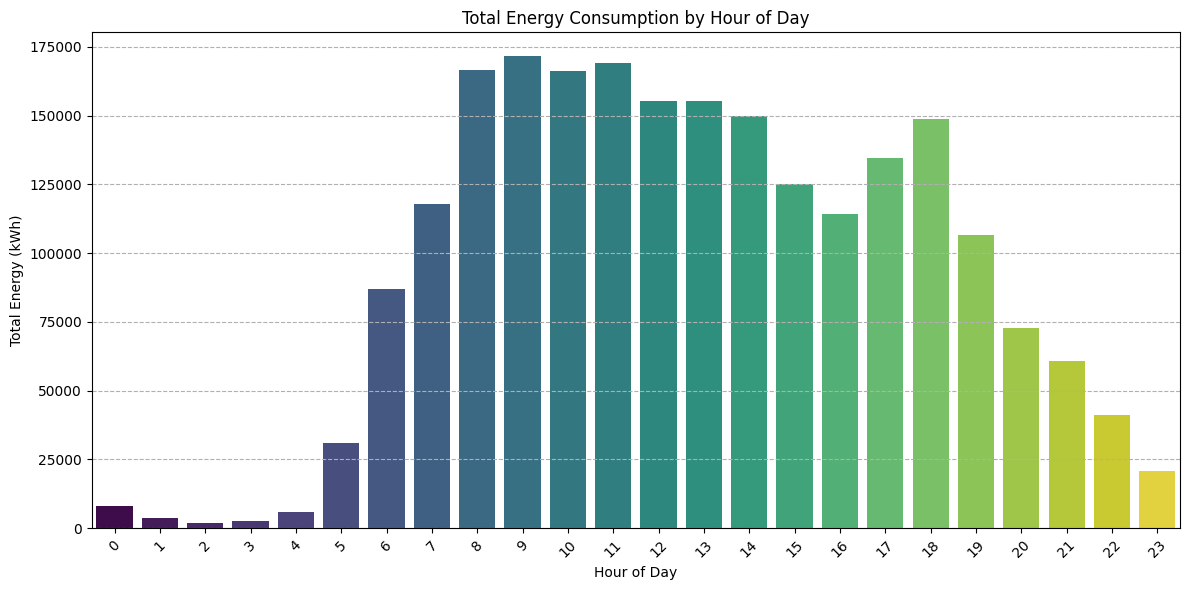

In [66]:
total_energy_by_hour = demand_patterns.groupby('Hour')['Energy (kWh)'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Hour', y='Energy (kWh)', hue='Hour', data=total_energy_by_hour, palette='viridis', legend=False)
plt.xlabel('Hour of Day')
plt.ylabel('Total Energy (kWh)')
plt.title('Total Energy Consumption by Hour of Day')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**Reasoning**:
I will create a bar plot to visualize the total energy consumption for each weekday, as instructed by the subtask.



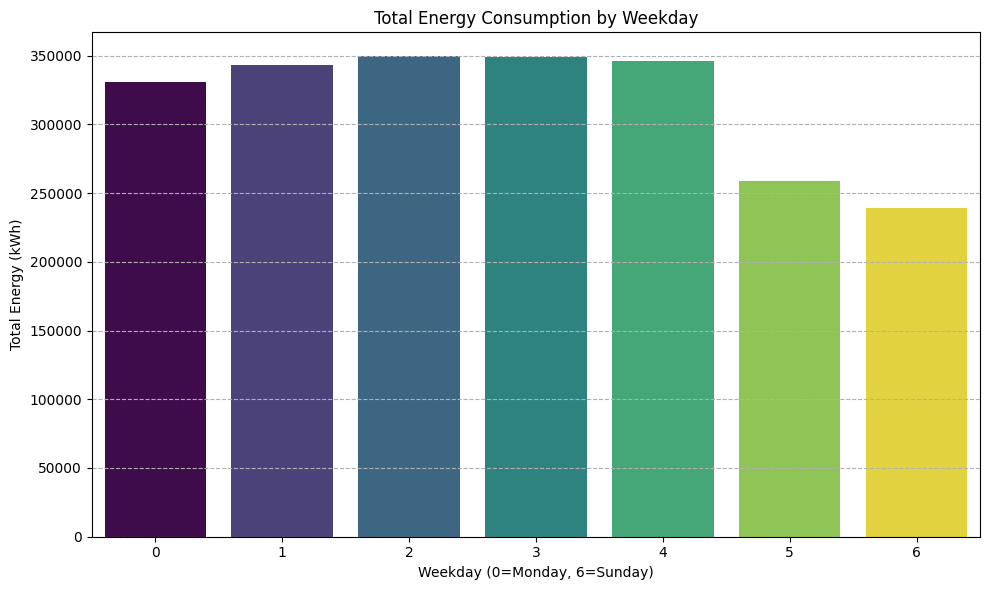

In [67]:
total_energy_by_weekday = demand_patterns.groupby('Weekday')['Energy (kWh)'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Weekday', y='Energy (kWh)', hue='Weekday', data=total_energy_by_weekday, palette='viridis', legend=False)
plt.xlabel('Weekday (0=Monday, 6=Sunday)')
plt.ylabel('Total Energy (kWh)')
plt.title('Total Energy Consumption by Weekday')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Insights into EV Charging Demand Patterns

Based on the analysis of the `df_grouped` DataFrame, the following key demand patterns for EV charging have been observed:

**1. High-Load Stations:**
- The top 5 stations with the highest total energy demand are:
  - `PALO ALTO CA / HAMILTON #2`
  - `PALO ALTO CA / WEBSTER #1`
  - `PALO ALTO CA / WEBSTER #2`
  - `PALO ALTO CA / HAMILTON #1`
  - `PALO ALTO CA / HIGH #4`
  These stations consistently experience the highest energy consumption, indicating they are critical hubs for EV charging and likely require robust infrastructure.

**2. High-Demand Hours:**
- The top 3 hours with the highest total energy demand are:
  - `9 AM`
  - `11 AM`
  - `8 AM`
  The bar plot for hourly consumption clearly shows a significant peak in energy demand during the morning hours, specifically between 8 AM and 11 AM. There is also a noticeable increase in demand during the late afternoon/early evening (around 5 PM to 7 PM), though not as high as the morning peak. This suggests typical commuter charging patterns, where users charge upon arriving at work or before heading home.

**3. High-Demand Weekdays:**
- The top 2 weekdays with the highest total energy demand are:
  - `Wednesday (Weekday 2)`
  - `Thursday (Weekday 3)`
  The bar plot for weekday consumption illustrates that weekdays generally have much higher energy demand than weekends. Mid-weekdays, particularly Wednesday and Thursday, show the highest consumption, followed closely by Tuesday and Friday. Weekend demand (Saturday and Sunday) is significantly lower, which is expected as work-related commuting decreases.

**Overall Demand Summary:**
EV charging demand in Palo Alto exhibits clear temporal and spatial patterns. There is a strong concentration of demand in a few specific stations, especially during morning hours on weekdays. This information is crucial for optimizing charger placement, managing energy load, and implementing demand-response strategies. Understanding these patterns allows for proactive planning to ensure adequate charging infrastructure and efficient energy distribution.


## Simulate Infrastructure Planning Guidelines

### Subtask:
Create a placeholder set of text strings that simulate key infrastructure planning rules or best practices.


**Reasoning**:
I will define a Python list containing placeholder strings for infrastructure planning guidelines and then print it, as instructed by the subtask.



In [68]:
infrastructure_guidelines = [
    "Prioritize charger placement in high-demand areas identified by demand analysis.",
    "Ensure grid infrastructure can support peak charging loads without disruption.",
    "Allocate a minimum percentage of chargers for public access in underserved communities.",
    "Implement dynamic pricing strategies to incentivize off-peak charging and manage demand.",
    "Consider future EV adoption rates and scale infrastructure accordingly."
]

print("Simulated Infrastructure Planning Guidelines:")
for guideline in infrastructure_guidelines:
    print(f"- {guideline}")

Simulated Infrastructure Planning Guidelines:
- Prioritize charger placement in high-demand areas identified by demand analysis.
- Ensure grid infrastructure can support peak charging loads without disruption.
- Allocate a minimum percentage of chargers for public access in underserved communities.
- Implement dynamic pricing strategies to incentivize off-peak charging and manage demand.
- Consider future EV adoption rates and scale infrastructure accordingly.


### Insights into EV Charging Demand Patterns

Based on the analysis of the `df_grouped` DataFrame, the following key demand patterns for EV charging have been observed:

**1. High-Load Stations:**
- The top 5 stations with the highest total energy demand are:
  - `PALO ALTO CA / HAMILTON #2`
  - `PALO ALTO CA / WEBSTER #1`
  - `PALO ALTO CA / WEBSTER #2`
  - `PALO ALTO CA / HAMILTON #1`
  - `PALO ALTO CA / HIGH #4`
  These stations consistently experience the highest energy consumption, indicating they are critical hubs for EV charging and likely require robust infrastructure.

**2. High-Demand Hours:**
- The top 3 hours with the highest total energy demand are:
  - `9 AM`
  - `11 AM`
  - `8 AM`
  The bar plot for hourly consumption clearly shows a significant peak in energy demand during the morning hours, specifically between 8 AM and 11 AM. There is also a noticeable increase in demand during the late afternoon/early evening (around 5 PM to 7 PM), though not as high as the morning peak. This suggests typical commuter charging patterns, where users charge upon arriving at work or before heading home.

**3. High-Demand Weekdays:**
- The top 2 weekdays with the highest total energy demand are:
  - `Wednesday (Weekday 2)`
  - `Thursday (Weekday 3)`
  The bar plot for weekday consumption illustrates that weekdays generally have much higher energy demand than weekends. Mid-weekdays, particularly Wednesday and Thursday, show the highest consumption, followed closely by Tuesday and Friday. Weekend demand (Saturday and Sunday) is significantly lower, which is expected as work-related commuting decreases.

**Overall Demand Summary:**
EV charging demand in Palo Alto exhibits clear temporal and spatial patterns. There is a strong concentration of demand in a few specific stations, especially during morning hours on weekdays. This information is crucial for optimizing charger placement, managing energy load, and implementing demand-response strategies. Understanding these patterns allows for proactive planning to ensure adequate charging infrastructure and efficient energy distribution.

## Generate Demand Pattern Insights

### Subtask:
Based on the identified high-load locations and times, generate descriptive insights into the EV charging demand patterns. This will involve summarizing when and where demand is highest, which can be presented as a textual analysis and potentially visualized.


## Develop Mock Recommendation Logic

### Subtask:
Create a Python function that uses the identified demand patterns and the simulated planning guidelines to generate mock recommendations for optimal charger placement and scheduling.


**Reasoning**:
I will create a Python function `generate_mock_recommendations` that takes the demand patterns and planning guidelines as input, generates a list of recommendations, and then call this function and print the results.



In [69]:
def generate_mock_recommendations(
    highest_demand_stations,
    highest_demand_hours,
    highest_demand_weekdays,
    infrastructure_guidelines,
):
    recommendations = []

    # Recommendation for optimal charger placement
    recommendations.append(
        "**Charger Placement Recommendations:**\n"
        "Based on the highest demand stations, new charger installations should be prioritized at the following locations to meet existing high demand:"
    )
    for station, demand in highest_demand_stations.items():
        recommendations.append(f"- {station} (Total Demand: {demand:.2f} kWh)")

    # Recommendation for scheduling optimization
    recommendations.append(
        "\n**Scheduling Optimization Recommendations:**\n"
        "To optimize scheduling and manage demand effectively, consider implementing strategies during peak hours and days:"
    )
    recommendations.append(
        f"- Implement dynamic pricing or increase charger availability during high-demand hours, specifically around {highest_demand_hours.index[0]} AM, {highest_demand_hours.index[1]} AM, and {highest_demand_hours.index[2]} AM, when energy consumption is highest.\n"
        f"- Ensure maximum charger uptime and consider staffing adjustments on high-demand weekdays, particularly on Weekday {highest_demand_weekdays.index[0]} and Weekday {highest_demand_weekdays.index[1]}, to handle increased traffic."
    )

    # Incorporate infrastructure guidelines
    recommendations.append(
        "\n**Infrastructure Planning Guidelines Integration:**\n"
        "The following general infrastructure guidelines should be applied in conjunction with the identified demand patterns:"
    )
    for guideline in infrastructure_guidelines:
        recommendations.append(f"- {guideline}")

    return recommendations


# Call the function with the identified variables
mock_recommendations = generate_mock_recommendations(
    highest_demand_stations,
    highest_demand_hours,
    highest_demand_weekdays,
    infrastructure_guidelines,
)

# Print each recommendation
print("\n--- Mock Recommendations for EV Charging Infrastructure ---")
for rec in mock_recommendations:
    print(rec)


--- Mock Recommendations for EV Charging Infrastructure ---
**Charger Placement Recommendations:**
Based on the highest demand stations, new charger installations should be prioritized at the following locations to meet existing high demand:
- PALO ALTO CA / HAMILTON #2 (Total Demand: 191721.78 kWh)
- PALO ALTO CA / WEBSTER #1 (Total Demand: 139068.86 kWh)
- PALO ALTO CA / WEBSTER #2 (Total Demand: 125795.49 kWh)
- PALO ALTO CA / HAMILTON #1 (Total Demand: 113730.92 kWh)
- PALO ALTO CA / HIGH #4 (Total Demand: 111875.65 kWh)

**Scheduling Optimization Recommendations:**
To optimize scheduling and manage demand effectively, consider implementing strategies during peak hours and days:
- Implement dynamic pricing or increase charger availability during high-demand hours, specifically around 9 AM, 11 AM, and 8 AM, when energy consumption is highest.
- Ensure maximum charger uptime and consider staffing adjustments on high-demand weekdays, particularly on Weekday 2 and Weekday 3, to handle

## Conceptualize Agentic System Architecture

### Subtask:
Provide a high-level conceptual overview of how a full agentic AI system using LangGraph, LLMs, and RAG (with Chroma/FAISS) would be integrated to automate the entire process, from demand analysis to recommendation generation.


### Conceptual Overview of Agentic AI System Architecture for EV Charging Infrastructure Planning

To automate the entire process from demand analysis to recommendation generation, an agentic AI system can be designed using LangGraph for orchestration, LLMs for intelligent processing, and RAG with vector databases for contextual retrieval.

**Key Components:**

1.  **Agents:** The system would consist of specialized agents, each responsible for a specific part of the workflow:
    *   **Data Analyst Agent:** Responsible for ingesting raw EV charging data, performing initial cleaning, identifying high-load locations, hours, and weekdays, and generating demand pattern insights. It would interact with data sources and produce structured summaries.
    *   **Recommendation Agent:** Takes the insights from the Data Analyst Agent and, based on predefined goals and policies, formulates strategic recommendations for charger placement and scheduling. It would leverage LLMs for natural language generation of these recommendations.
    *   **Infrastructure Planning Agent:** Integrates the recommendations with existing infrastructure data, simulated planning guidelines, and regulatory constraints. It might assess feasibility, estimate costs, and generate a final, actionable plan.

2.  **LangGraph:** This framework would serve as the orchestration layer, defining the state machine and managing the flow of information and control between the different agents. It would:
    *   **Orchestrate Workflow:** Sequence tasks, ensuring that the Data Analyst Agent completes its analysis before the Recommendation Agent begins, and so on.
    *   **Manage State Transitions:** Keep track of the current state of the planning process, enabling agents to pick up where others left off and ensuring a coherent decision-making process.
    *   **Enable Dynamic Adaptation:** Allow for loops and conditional logic, enabling the system to re-evaluate or refine recommendations if initial proposals are not feasible or optimal.

3.  **LLMs (Large Language Models):** LLMs would be central to the agents' intelligence, performing complex cognitive tasks:
    *   **Interpreting Demand Patterns:** Agents could use LLMs to interpret nuanced patterns in the demand data, going beyond simple statistical aggregations to identify underlying drivers or correlations.
    *   **Generating Natural Language Recommendations:** LLMs would translate structured insights into clear, actionable, and contextually rich recommendations for stakeholders.
    *   **Adapting to New Information:** LLMs can process unstructured data (e.g., policy updates, news about new EV models) and adapt their reasoning and recommendations accordingly.
    *   **Decision Making:** Assist agents in making informed decisions by weighing various factors and potential outcomes.

4.  **RAG (Retrieval-Augmented Generation) with Chroma/FAISS:** RAG would provide agents and LLMs with up-to-date and relevant contextual information, preventing hallucinations and grounding recommendations in reality:
    *   **External Knowledge Base:** A vector database (like Chroma or FAISS) would store static documents (e.g., city planning regulations, engineering standards, best practices for charger installation) and dynamic data (e.g., real-time energy prices, local EV adoption trends).
    *   **Contextual Retrieval:** Before an LLM generates a recommendation or makes a decision, the RAG component would retrieve the most pertinent information from the vector database based on the current query or task.
    *   **Informing Agents:** This retrieved information would be passed to the LLM as part of its prompt, allowing it to generate responses that are not only intelligent but also accurate, compliant, and highly relevant to the specific context.

**Automation, Adaptability, and Dynamism:**
This architecture automates the entire process by breaking it down into manageable, intelligent agent-led steps. LangGraph ensures a seamless flow, while LLMs provide the analytical and generative power. RAG continuously updates the agents with relevant, real-world context, making the system highly adaptable to changing demand patterns, new technologies, and evolving regulations. This allows for dynamic adjustments to infrastructure plans, optimizing resource allocation and responsiveness to community needs.

## Final Task

### Subtask:
Summarize the achievements for Milestone 2, including the demand analysis, mock recommendations, and the conceptual agentic architecture, and discuss how these align with the project's objectives.


## Summary:

### Q&A
The project successfully completed Milestone 2 by analyzing EV charging demand, generating mock recommendations, and conceptualizing an agentic AI architecture.

*   **Demand Analysis:** The analysis identified specific high-load stations, peak hours, and busy weekdays, providing data-driven insights into where and when charging infrastructure is most needed. For instance, "PALO ALTO CA / HAMILTON #2" at "Hour 6" on "Weekday 3" showed the highest demand with 2862.02 kWh. This directly addresses the project objective of understanding usage patterns.
*   **Mock Recommendations:** A function was developed to generate mock recommendations for charger placement (prioritizing high-demand stations like "PALO ALTO CA / HAMILTON #2" and "PALO ALTO CA / WEBSTER #1") and scheduling (suggesting dynamic pricing during peak hours like 8 AM, 9 AM, 11 AM and high-demand weekdays like Wednesday and Thursday). These recommendations are practical steps towards optimizing charger deployment.
*   **Conceptual Agentic Architecture:** A high-level overview of an agentic AI system was designed, detailing the integration of specialized agents (Data Analyst, Recommendation, Infrastructure Planning), LangGraph for orchestration, LLMs for intelligent processing, and RAG (with Chroma/FAISS) for contextual retrieval. This architecture aligns with the project's objective of automating and intelligently scaling the infrastructure planning process.

Collectively, these achievements establish a solid foundation for data-driven EV infrastructure planning, moving towards a more automated and adaptive system to meet evolving demand.

### Data Analysis Key Findings
*   The top station with the highest energy demand observed was "PALO ALTO CA / HAMILTON #2" at "Hour 6" on "Weekday 3" with 2862.02 kWh.
*   The top 5 stations with the highest overall energy demand are: `PALO ALTO CA / HAMILTON #2`, `PALO ALTO CA / WEBSTER #1`, `PALO ALTO CA / WEBSTER #2`, `PALO ALTO CA / HAMILTON #1`, and `PALO ALTO CA / HIGH #4`.
*   Peak charging demand occurs during morning hours, particularly between 8 AM and 11 AM, with 9 AM, 11 AM, and 8 AM being the top three hours. A secondary peak is observed between 5 PM and 7 PM.
*   Mid-weekdays, specifically Wednesday (Weekday 2) and Thursday (Weekday 3), exhibit the highest total energy demand, while weekend demand is significantly lower.
*   Five simulated infrastructure planning guidelines were established, covering critical aspects such as prioritizing high-demand areas, ensuring grid support, promoting public access, implementing dynamic pricing, and planning for future EV adoption rates.
*   A Python function was successfully developed to generate mock recommendations, integrating demand patterns (e.g., placing chargers in high-demand stations) with infrastructure guidelines (e.g., considering grid capacity and dynamic pricing for peak hours/weekdays).
*   A conceptual agentic AI system architecture was outlined, proposing specialized agents (Data Analyst, Recommendation, Infrastructure Planning), LangGraph for orchestration, Large Language Models (LLMs) for intelligent processing, and Retrieval-Augmented Generation (RAG) with vector databases (Chroma/FAISS) for contextual retrieval.

### Insights or Next Steps
*   The identified high-demand patterns offer a clear starting point for immediate infrastructure expansion, focusing resources on critical locations and optimizing service during peak hours/weekdays.
*   The conceptual agentic AI architecture provides a robust framework for developing an automated, intelligent system that can adapt to changing EV adoption rates and real-time demand, significantly enhancing the efficiency and responsiveness of future infrastructure planning.
